Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)

Target names:
['malignant' 'benign']

Training data: (455, 30)
Testing data: (114, 30)

Feature Scaling Completed
Logistic Regression Model Created
Model Training Completed
Prediction Completed

Predictions:
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]

Confusion Matrix:
[[41  2]
 [ 1 70]]

Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1-Score: 0.9790209790209791


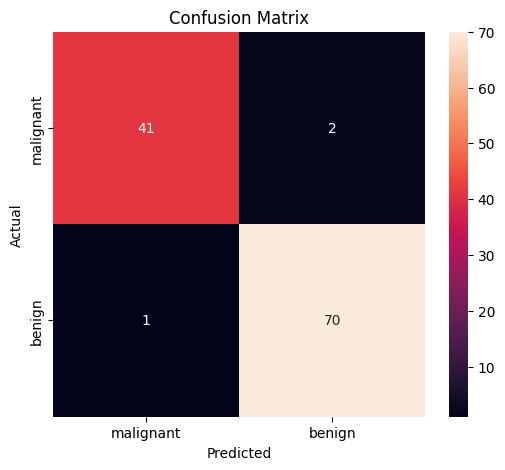

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Target names
print("\nTarget names:")
print(data.target_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed")

# Create Logistic Regression model
model = LogisticRegression(max_iter=5000)

print("Logistic Regression Model Created")

# Train model
model.fit(X_train, y_train)

print("Model Training Completed")

# Prediction
y_pred = model.predict(X_test)

print("Prediction Completed")
print("\nPredictions:")
print(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()